<div style="background:#FFF5F8;border:3px solid #E0218A;border-radius:16px;padding:28px;text-align:center;">
<h1 style="color:#E0218A;margin:0;">🐥 Curso de Machine Learning · Clase 6 de 7</h1>
<h2 style="color:#1B2A5B;margin:10px 0 4px;">Overfitting en vivo, la auditoría del regulador</h2>
<p style="color:#1B2A5B;margin:6px 0;">Con la Miss Yera · <a href="https://missyera.com">missyera.com</a> · @soymissyera</p>
<p style="color:#E0218A;margin:0;"><b>Regla de oro del curso, nadie ejecuta una celda sin predecir en voz alta qué va a pasar.</b></p>
</div>

## 🧭 ¿Dónde estamos en el curso?

Progreso, 🐥🐥🐥🐥🐥🐥▫️ · clase 6 de 7

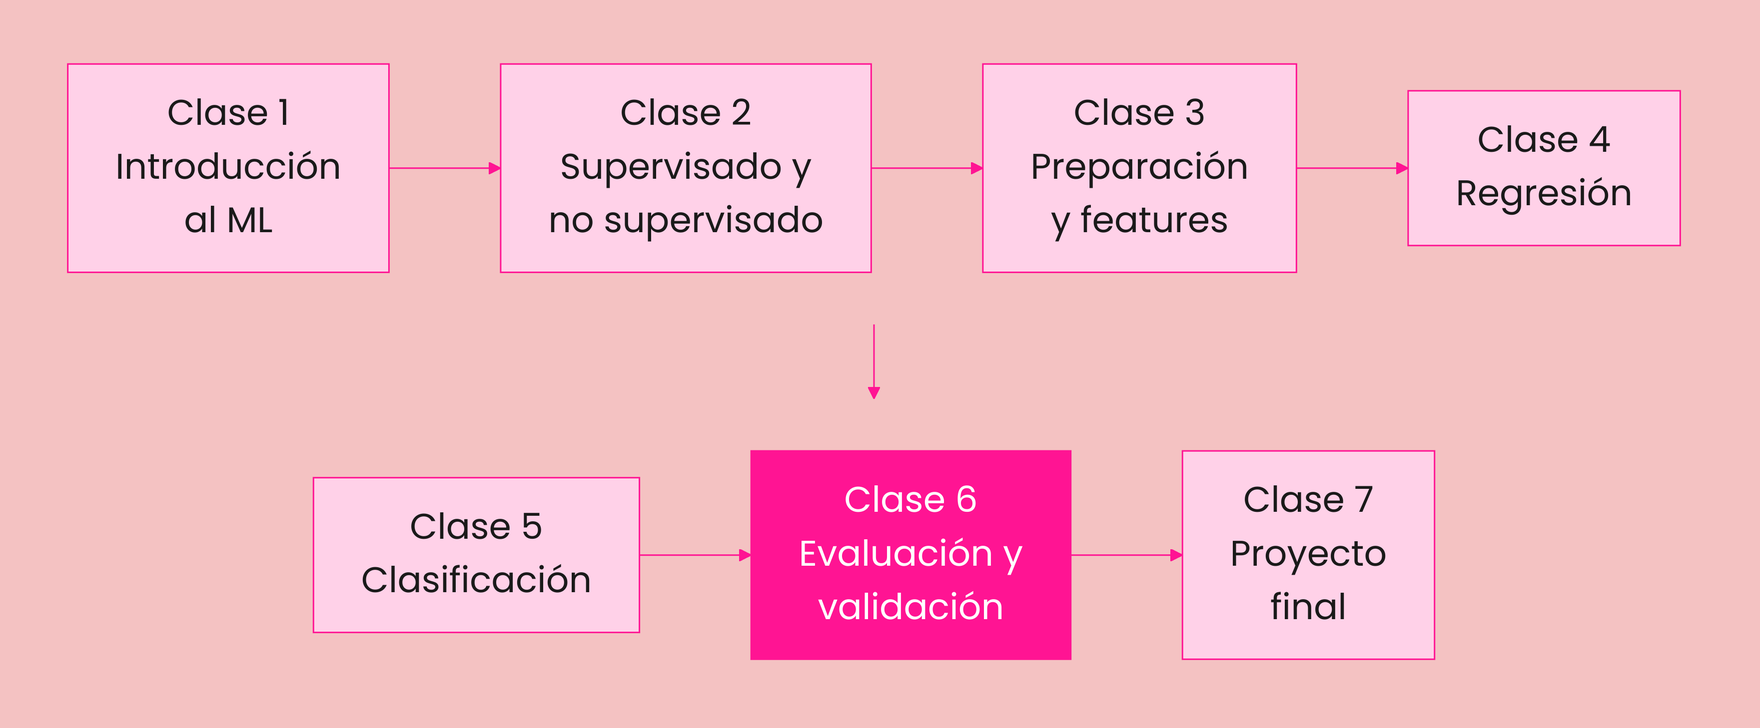


## 🔁 Antes de arrancar, 60 segundos de la clase anterior

En la clase 5, clasificación, ¿quién caerá en mora? cada error cuesta soles, dejamos lista la base para lo de hoy. Si algo de lo que sigue no te suena, regresa a ese notebook o al video de la clase 5 de la playlist antes de continuar.


In [1]:
#@title 🎬 Toca play · Quiz de entrada, ¿qué te llevaste de la clase anterior?
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de entrada, ¿qué te llevaste de la clase anterior?</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. En PolliCreditos, ¿cuál es el error más caro del modelo de mora?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_0" value="0"> El falso positivo, rechazar a un bueno</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_0" value="1"> El falso negativo, el préstamo perdido</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_0" value="2"> El verdadero positivo</label><div id="qin6_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. ¿Quién decide el umbral de la alerta de mora?</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_1" value="0"> El modelo automáticamente</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_1" value="1"> scikit-learn</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qin6_1" value="2"> El negocio, según el costo de cada error</label><div id="qin6_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "es el que se escap\u00f3 sin alerta"], [2, "la perilla no es t\u00e9cnica, es de negocio"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qin6_"+i+"\']:checked");
        var fb=document.getElementById("qin6_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

## 🎯 Lo que vas a lograr hoy

- Provocar el overfitting a propósito y verlo reventar en el examen sorpresa.
- Curarlo limitando la complejidad y confirmarlo con validación cruzada de cinco exámenes.
- Cerrar con el protocolo profesional, el test se toca UNA sola vez.


## 📩 El pedido de la semana en PolliCreditos

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><i>"El regulador nos audita el modelo el viernes. Demuéstrame que aprende y no memoriza, y que el examen final es honesto, sin trampa."</i><br><b style="color:#1B2A5B;">El CEO de PolliCreditos 🐥</b></div>



<div style="background: linear-gradient(135deg, #FF1493 0%, #FF69B4 55%, #FFB6C1 100%); border-radius: 22px; padding: 42px 36px; text-align: center; color: white; font-family: 'Inter', sans-serif;">
  <div style="font-size: 15px; letter-spacing: 3px; opacity: .95;">🐤 CURSO DE MACHINE LEARNING · CLASE 06</div>
  <h1 style="margin: 14px 0 6px 0; font-size: 40px; color: white;">Evaluación y validación de modelos</h1>
  <div style="font-size: 18px; opacity: .96;">El arte de no mentirte a ti misma con las métricas</div>
  <div style="margin-top: 22px; font-size: 14px; background: rgba(255,255,255,.18); display: inline-block; padding: 8px 20px; border-radius: 999px;">Miss Yera · missyera.com · @soymissyera</div>
</div>



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 17px;">🎯 Al final de esta clase vas a poder</b>
<ul style="margin-top: 10px;"><li>Provocar y diagnosticar overfitting en vivo</li>
<li>Aplicar validación cruzada para estimaciones honestas</li>
<li>Ajustar hiperparámetros con GridSearchCV sin tocar el test</li>
<li>Leer curvas de validación y de aprendizaje</li>
<li>Cerrar con el protocolo de evaluación profesional completo</li></ul>
</div>


In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Paleta oficial Miss Yera para todos los gráficos de la clase
YERA = ['#FF1493', '#FF69B4', '#FFB6C1', '#00C9A7', '#FFC75F', '#1B2A5B']
plt.rcParams.update({
    'figure.figsize': (9, 5),
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.prop_cycle': plt.cycler(color=['#FF1493', '#00C9A7', '#1B2A5B', '#FFC75F', '#FF69B4']),
})
np.random.seed(42)  # semilla fija, reproducible o no existe
print('Setup listo, pollito 🐥')

Setup listo, pollito 🐥


## 1. El experimento de la trampa, overfitting en vivo

Vamos a entrenar un árbol sin límites y ver cómo se convierte en un memorión, perfecto en el estudio, desastroso en el examen sorpresa.

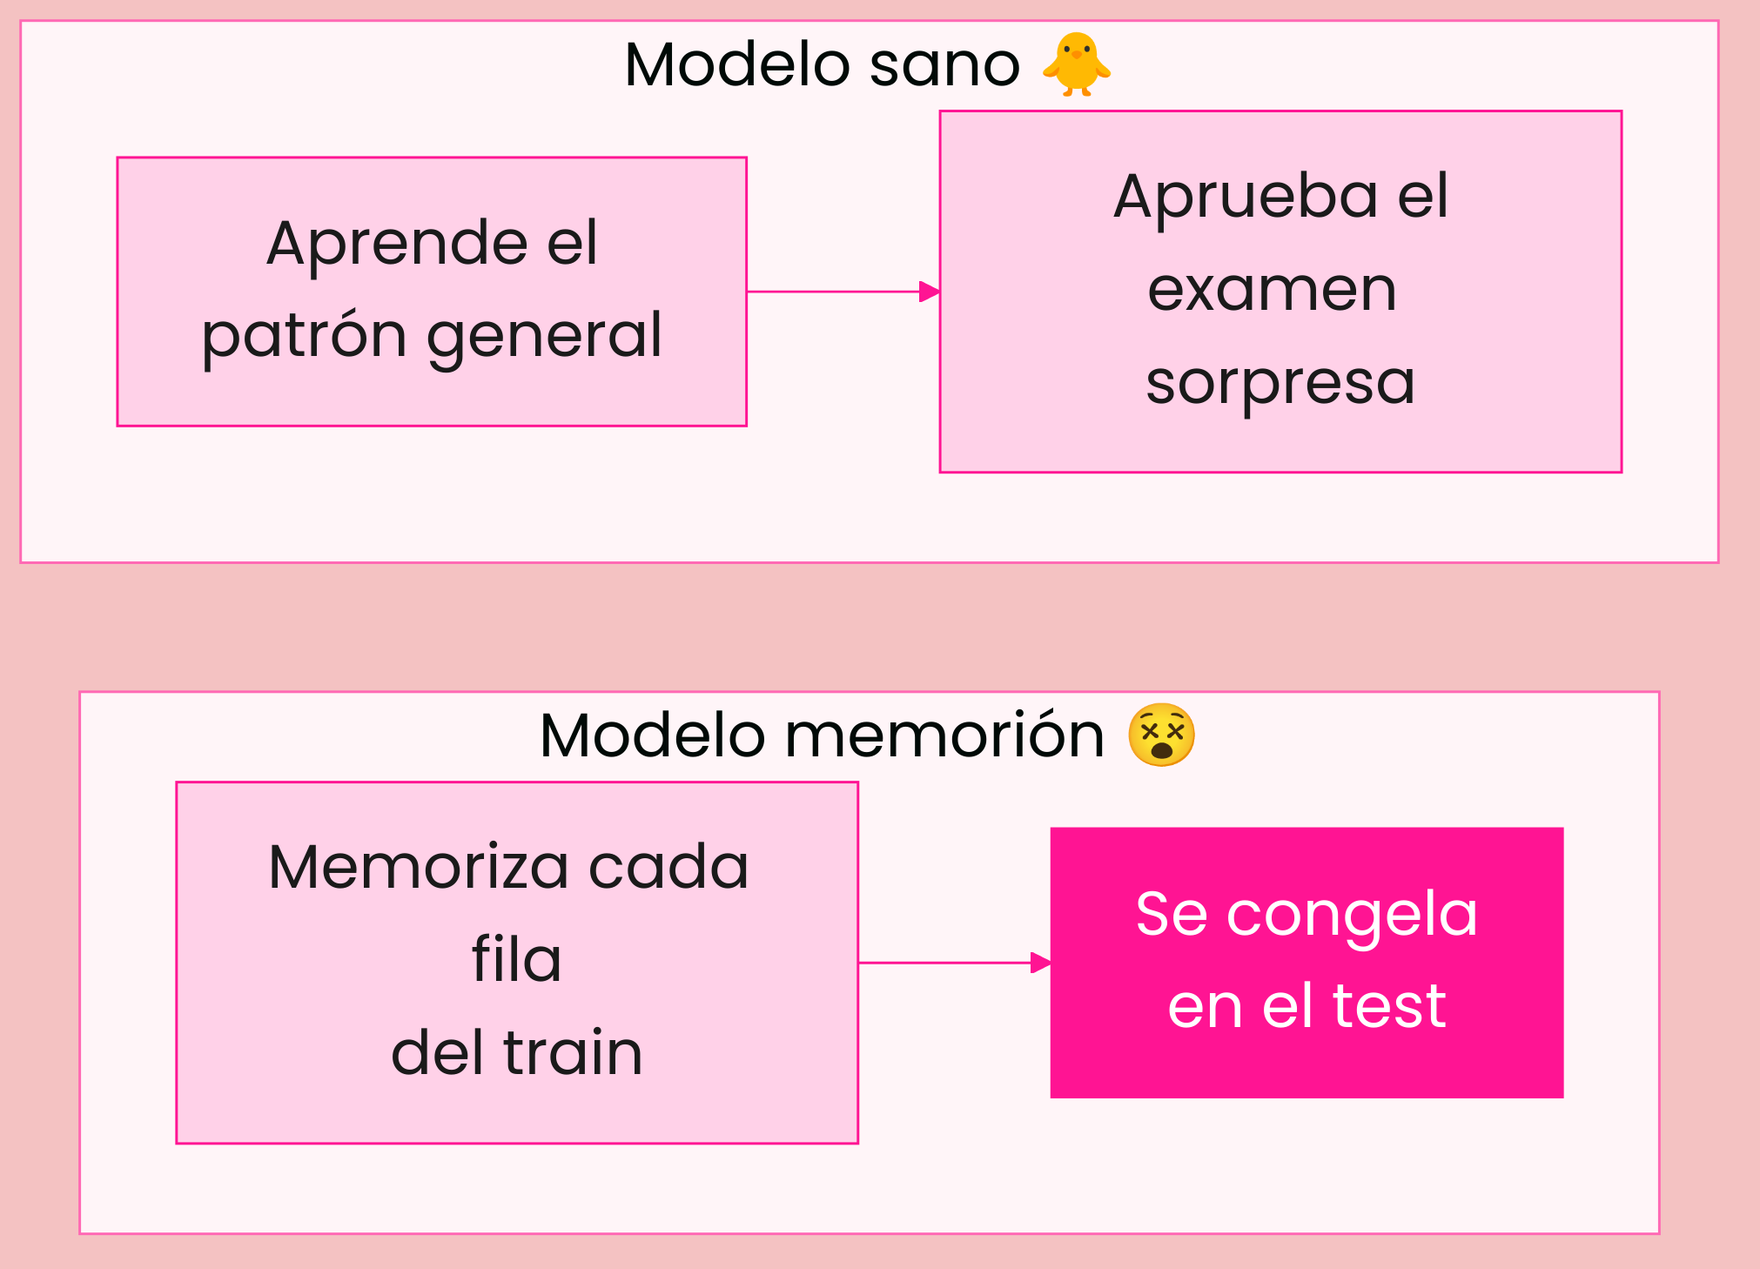

*El modelo memorión saca 100 en el train y se congela en el test, aprender no es memorizar.*


In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

np.random.seed(42)
n = 500

# Dataset con traslape real entre clases, como la vida misma
X = pd.DataFrame({
    "ingreso": np.random.normal(4000, 1500, n),
    "deuda": np.random.normal(2500, 1200, n),
    "edad": np.random.randint(20, 65, n),
})
puntaje = (X["deuda"] / X["ingreso"].clip(500) + np.random.normal(0, 0.45, n))
y = (puntaje > 0.68).astype(int)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

# El memorión, un árbol sin ningún límite de profundidad
memorion = DecisionTreeClassifier(random_state=42)
memorion.fit(X_train, y_train)

print(f"El memorión en TRAIN, {memorion.score(X_train, y_train):.1%}  ← perfecto, sospechoso")
print(f"El memorión en TEST,  {memorion.score(X_test, y_test):.1%}  ← la caída delatora")
print(f"Profundidad que alcanzó, {memorion.get_depth()} niveles de memorización")

El memorión en TRAIN, 100.0%  ← perfecto, sospechoso
El memorión en TEST,  68.7%  ← la caída delatora
Profundidad que alcanzó, 20 niveles de memorización



<div style="background: #FFF5F8; border: 2px dashed #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#1B2A5B; font-size: 16px;">📖 Concepto nuevo, <span style="color:#FF1493;">Overfitting</span></b><br>
El modelo memoriza el ruido y las particularidades del train en lugar de aprender el patrón general, por eso brilla en train y fracasa con datos nuevos.<br>
<i>🐥 En idioma pollito, Es el pollito memorión que se aprendió el solucionario de memoria. En la práctica del cuaderno saca veinte, en el examen sorpresa con ejercicios nuevos se hunde, porque nunca entendió el método.</i>
</div>


## 2. La cura, limitar la complejidad

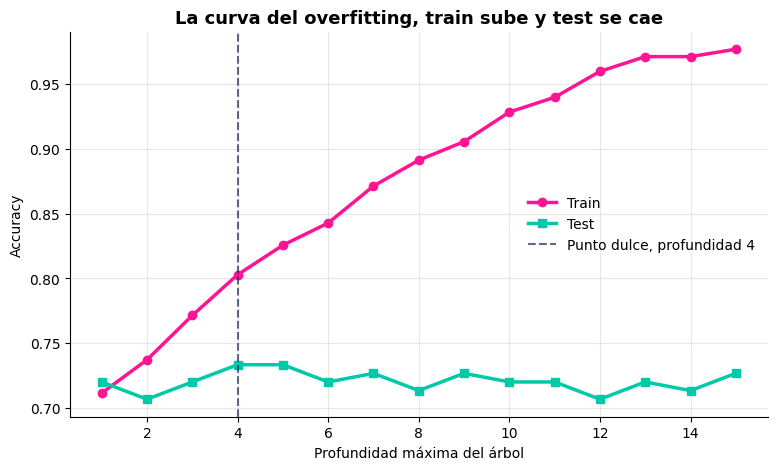

El punto dulce está en profundidad 4, después de ahí el árbol memoriza


In [4]:
profundidades = range(1, 16)
scores_train, scores_test = [], []

for p in profundidades:
    arbol = DecisionTreeClassifier(max_depth=p, random_state=42)
    arbol.fit(X_train, y_train)
    scores_train.append(arbol.score(X_train, y_train))
    scores_test.append(arbol.score(X_test, y_test))

fig, ax = plt.subplots()
ax.plot(profundidades, scores_train, marker="o", label="Train", color=YERA[0], linewidth=2.5)
ax.plot(profundidades, scores_test, marker="s", label="Test", color=YERA[3], linewidth=2.5)
mejor = profundidades[int(np.argmax(scores_test))]
ax.axvline(mejor, linestyle="--", color=YERA[5], alpha=0.7, label=f"Punto dulce, profundidad {mejor}")
ax.set_title("La curva del overfitting, train sube y test se cae")
ax.set_xlabel("Profundidad máxima del árbol")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
plt.show()
print(f"El punto dulce está en profundidad {mejor}, después de ahí el árbol memoriza")


<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 Los porqués de esta celda</b><br>
A la izquierda el árbol es tan simple que ni siquiera aprende, eso es underfitting. A la derecha memoriza el ruido, overfitting. El punto dulce está donde el test alcanza su máximo. Este gráfico es el electrocardiograma de todo modelo y deberías dibujarlo siempre.
</div>


## 3. Validación cruzada, cinco exámenes en vez de uno

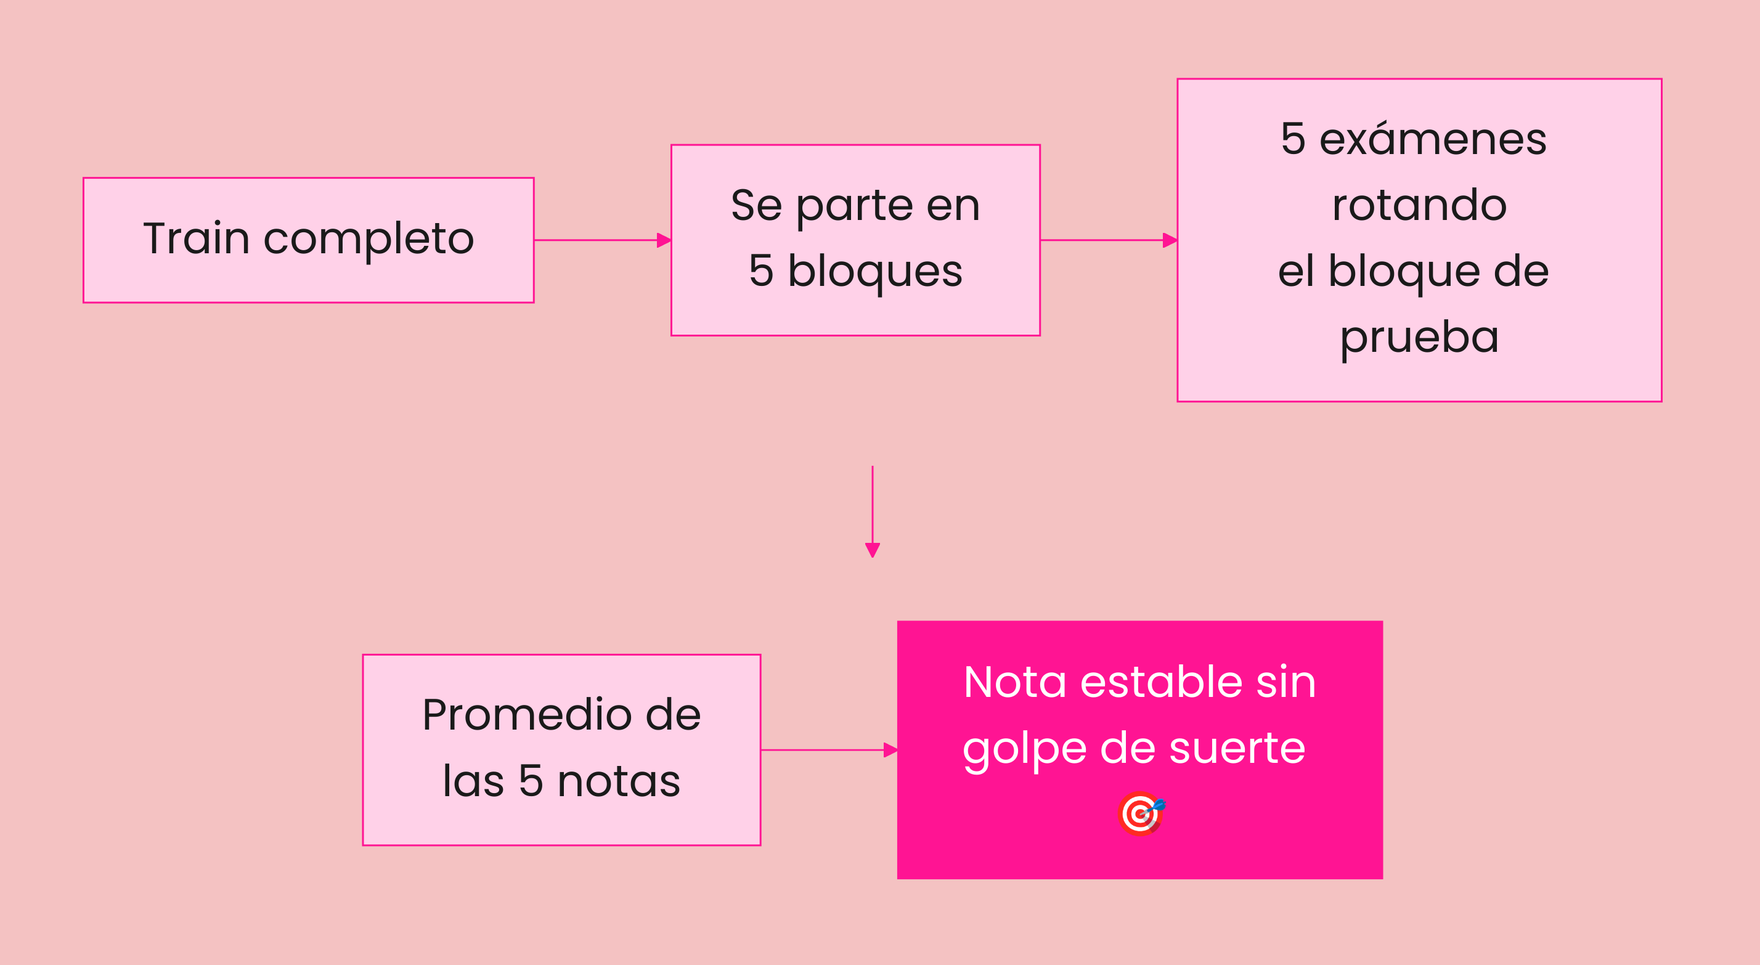

*Cinco exámenes rotando el bloque de prueba dan una nota estable, sin golpes de suerte.*


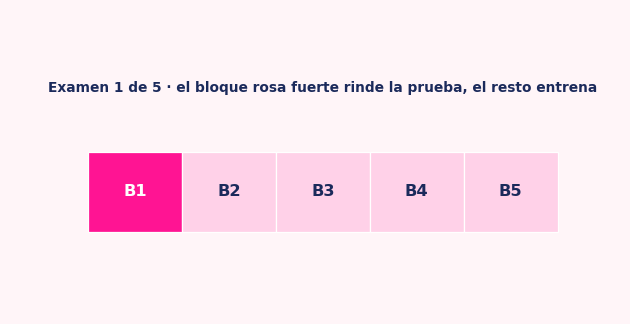

*Los cinco exámenes rotando, cada bloque rinde la prueba una vez.*


In [5]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

modelo = DecisionTreeClassifier(max_depth=4, random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(modelo, X_train, y_train, cv=cv, scoring="accuracy")

print("Los cinco exámenes,", scores.round(3))
print(f"Promedio, {scores.mean():.3f} ± {scores.std():.3f}")
print("\nUn solo split puede tener suerte o mala suerte,")
print("cinco splits rotados dan una nota honesta con su margen de duda")

Los cinco exámenes, [0.729 0.686 0.871 0.629 0.7  ]
Promedio, 0.723 ± 0.081

Un solo split puede tener suerte o mala suerte,
cinco splits rotados dan una nota honesta con su margen de duda



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 ¿Cómo funciona la validación cruzada?</b><br>
Parte el train en cinco pliegues. Entrena con cuatro y evalúa con el quinto, rotando cinco veces para que cada pliegue sea examen una vez. El promedio es la estimación honesta y la desviación te dice qué tan estable es el modelo. StratifiedKFold además mantiene el balance de clases en cada pliegue.
</div>


## 4. GridSearchCV, el buscador de la mejor configuración

In [6]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

parametros = {
    "n_estimators": [50, 150],
    "max_depth": [3, 5, 8],
    "min_samples_leaf": [1, 5],
}

busqueda = GridSearchCV(
    RandomForestClassifier(random_state=42),
    parametros, cv=5, scoring="f1", n_jobs=-1,
)
busqueda.fit(X_train, y_train)

print("Mejor configuración encontrada,", busqueda.best_params_)
print(f"Mejor F1 en validación cruzada, {busqueda.best_score_:.3f}")
print(f"\nCombinaciones evaluadas, {len(busqueda.cv_results_['params'])} configuraciones x 5 pliegues = {len(busqueda.cv_results_['params']) * 5} entrenamientos")

Mejor configuración encontrada, {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 150}
Mejor F1 en validación cruzada, 0.747

Combinaciones evaluadas, 12 configuraciones x 5 pliegues = 60 entrenamientos



<div style="background: #FFF5F8; border-left: 6px solid #FF69B4; border-radius: 12px; padding: 16px 22px;">
<b style="color:#FF1493;">🤔 La regla sagrada del tuning</b><br>
GridSearch busca la mejor configuración usando validación cruzada dentro del train. El test sigue guardado bajo llave y se usa una sola vez al final. Si eliges hiperparámetros mirando el test, el test deja de ser examen sorpresa y tus métricas son de mentira.
</div>


## 5. El examen final, una sola vez y con todo el boletín

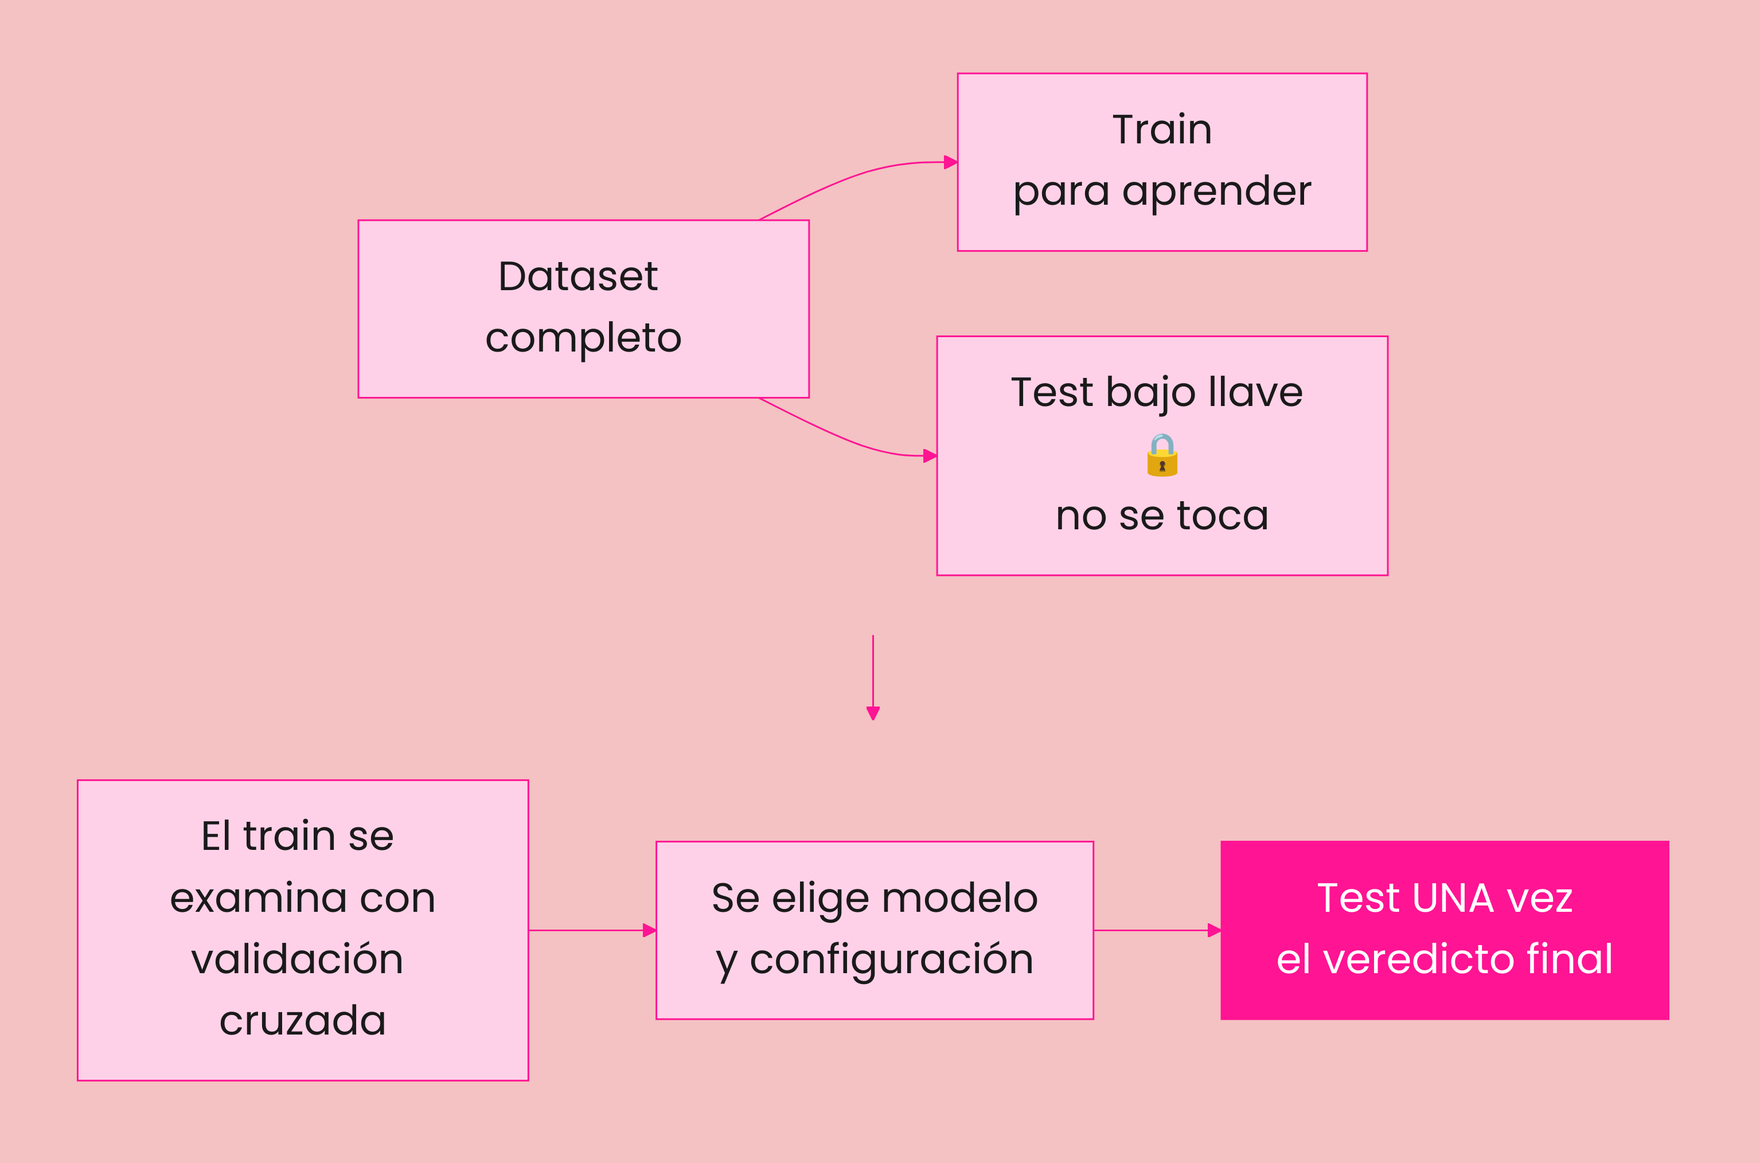

*El train se examina con validación cruzada, el test espera bajo llave para el veredicto final.*


### 🧮 La matemática detrás · Cálculo integral, el área bajo la curva

$AUC = \int_0^1 TPR \; d(FPR)$

**Lectura en palabras,** el AUC es el área bajo la curva ROC, una integral de toda la vida, y resume en un número qué tan bien separa tu modelo en todos los umbrales a la vez.

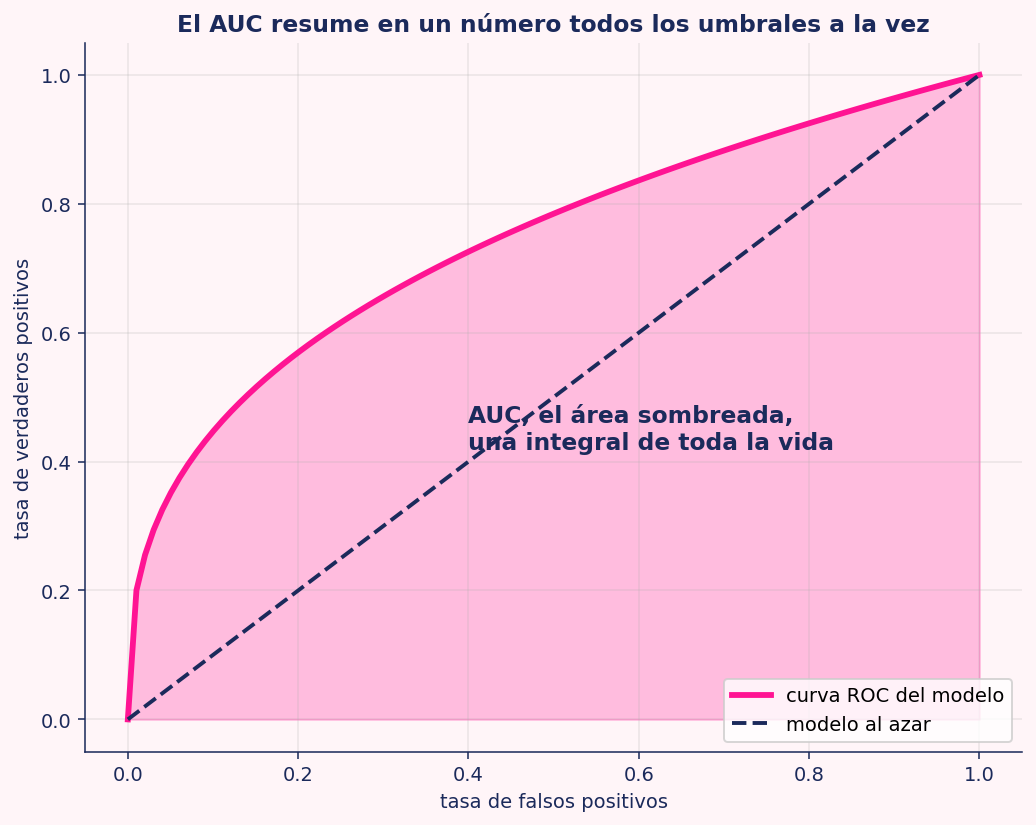

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;">🤔 <b>Por qué te sirve saberlo,</b> Las integrales también viven en la esperanza matemática y en toda la probabilidad continua, no eran solo tortura universitaria.<br><br>🐥 No necesitas dominar esto hoy, necesitas saber que existe y a qué puerta tocar cuando quieras profundizar.</div>


              precision    recall  f1-score   support

        Paga       0.75      0.74      0.75        77
      Impago       0.73      0.74      0.73        73

    accuracy                           0.74       150
   macro avg       0.74      0.74      0.74       150
weighted avg       0.74      0.74      0.74       150



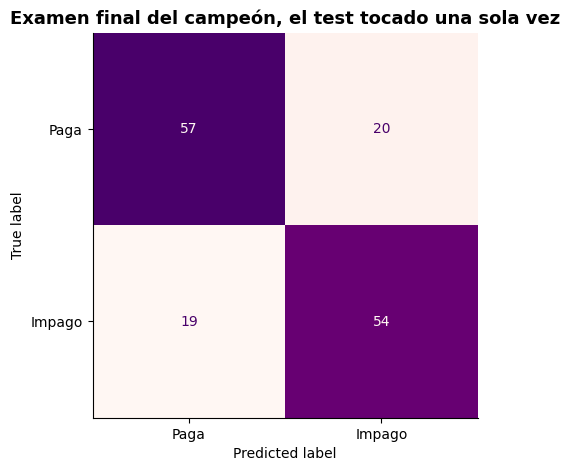

In [7]:
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

campeon = busqueda.best_estimator_
pred_final = campeon.predict(X_test)

print(classification_report(y_test, pred_final, target_names=["Paga", "Impago"]))

fig, ax = plt.subplots(figsize=(5.5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, pred_final,
    display_labels=["Paga", "Impago"], cmap="RdPu", ax=ax, colorbar=False)
ax.set_title("Examen final del campeón, el test tocado una sola vez")
ax.grid(False)
plt.show()

## 6. Curva de aprendizaje, ¿me faltan datos o me falta modelo?

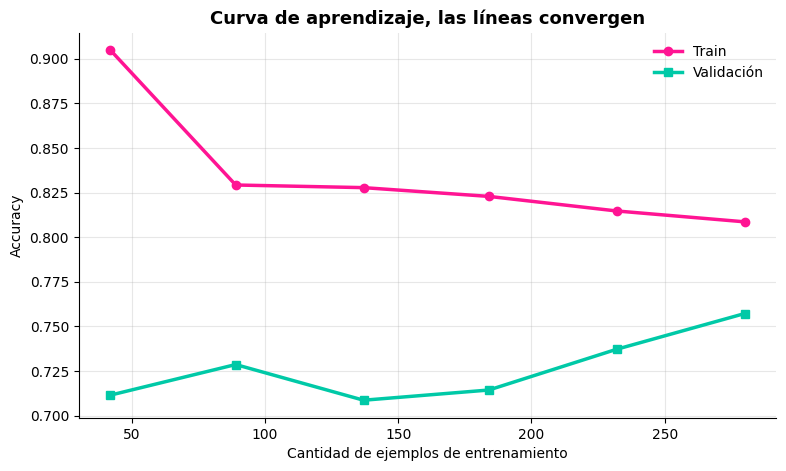

Si las curvas convergen, más datos ya no ayudan mucho,
si hay brecha grande entre ellas, el modelo pide más ejemplos o menos complejidad


In [8]:
from sklearn.model_selection import learning_curve

tamanios, sc_train, sc_val = learning_curve(
    campeon, X_train, y_train, cv=5,
    train_sizes=np.linspace(0.15, 1.0, 6), scoring="accuracy", n_jobs=-1,
)

fig, ax = plt.subplots()
ax.plot(tamanios, sc_train.mean(axis=1), marker="o", label="Train", color=YERA[0], linewidth=2.5)
ax.plot(tamanios, sc_val.mean(axis=1), marker="s", label="Validación", color=YERA[3], linewidth=2.5)
ax.set_title("Curva de aprendizaje, las líneas convergen")
ax.set_xlabel("Cantidad de ejemplos de entrenamiento")
ax.set_ylabel("Accuracy")
ax.legend(frameon=False)
plt.show()
print("Si las curvas convergen, más datos ya no ayudan mucho,")
print("si hay brecha grande entre ellas, el modelo pide más ejemplos o menos complejidad")

## 7. El protocolo profesional completo

- 1️⃣ Separar test y guardarlo bajo llave desde el minuto uno
- 2️⃣ Explorar y preparar los datos usando solo el train
- 3️⃣ Comparar modelos e hiperparámetros con validación cruzada
- 4️⃣ Elegir al campeón con la métrica que refleja el costo del negocio
- 5️⃣ Evaluar en test UNA sola vez, ese es el número que se reporta
- 6️⃣ Documentar semillas, versiones y decisiones, reproducible o no existe

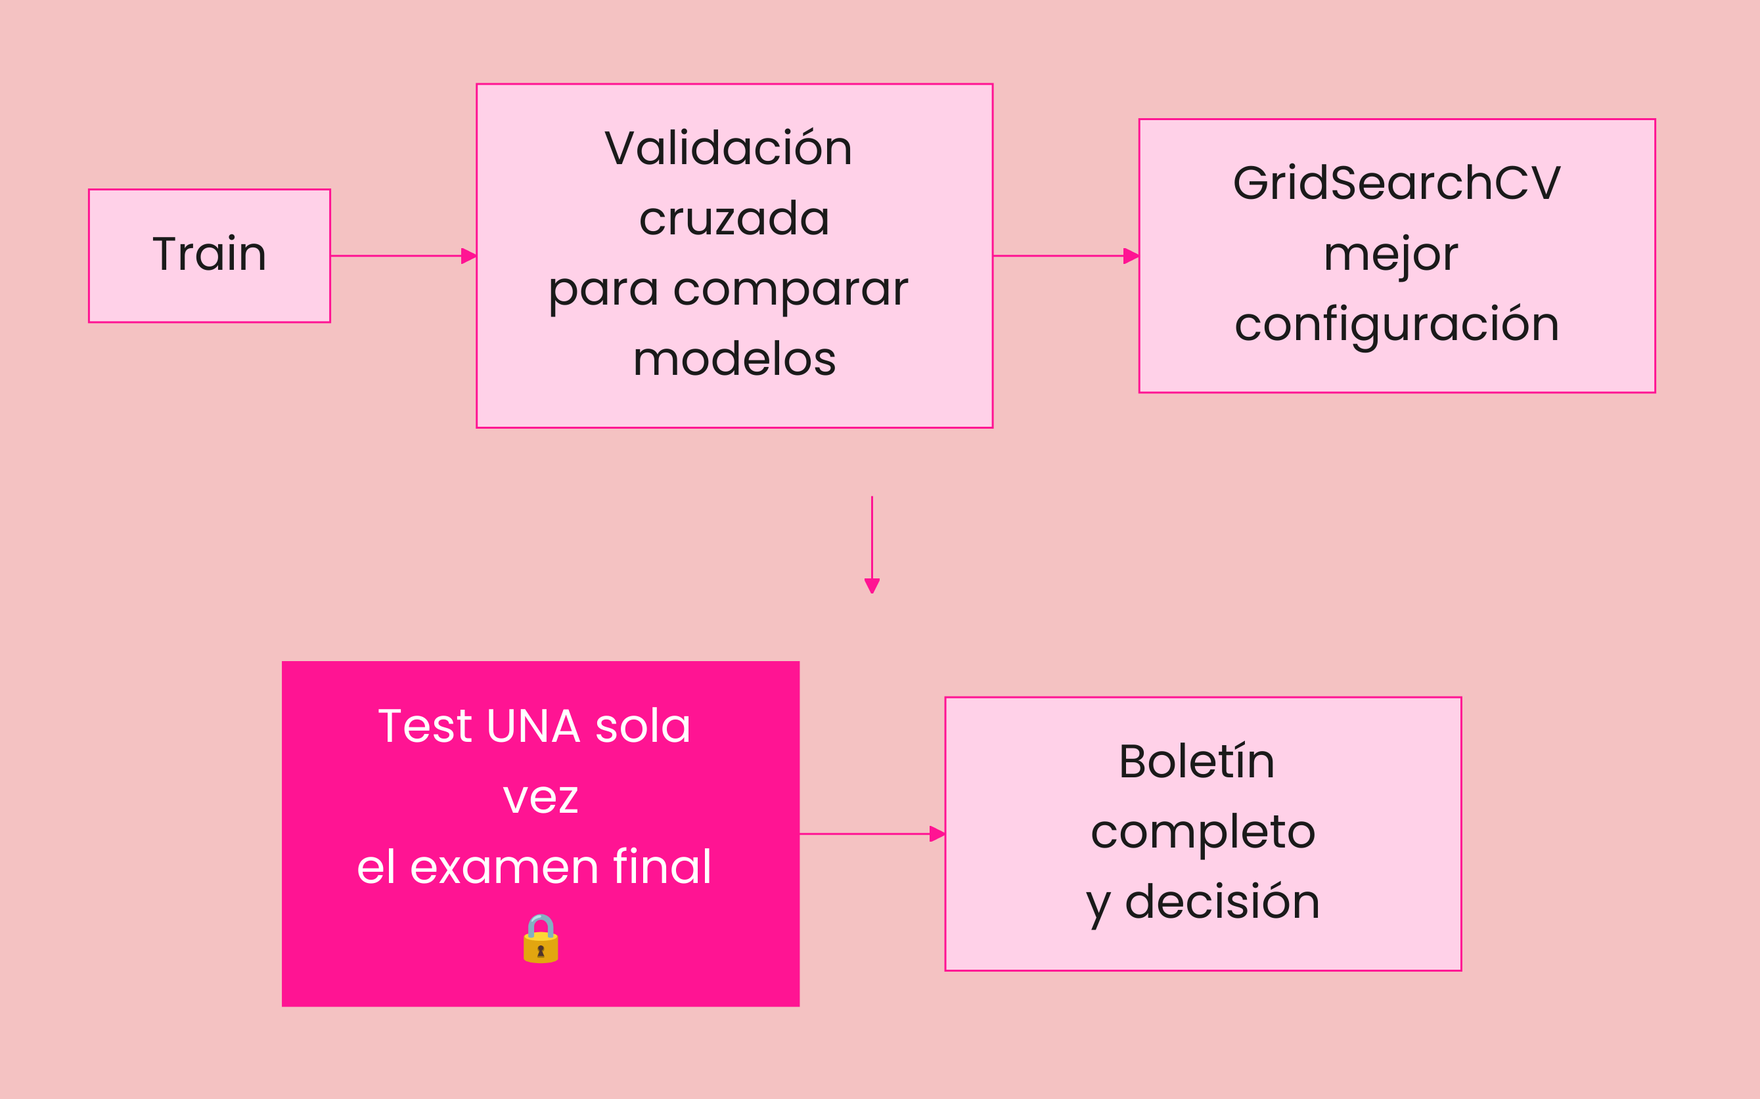

*Comparar con validación cruzada, afinar con GridSearchCV y recién ahí el test, una sola vez.*


## 8. Reto resuelto, auditar un flujo con trampa

El reto mostraba un flujo de evaluación con un error grave de data leakage y pedía detectarlo y corregirlo. Aquí el antes y el después.

In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# ❌ FLUJO CON TRAMPA, escala con TODOS los datos antes del split
escalador_tramposo = StandardScaler().fit(X)          # ← vio el test, pecado capital
X_escalado_mal = escalador_tramposo.transform(X)
Xtr_mal, Xte_mal, ytr_mal, yte_mal = train_test_split(X_escalado_mal, y, test_size=0.3, random_state=42, stratify=y)
modelo_mal = LogisticRegression(random_state=42).fit(Xtr_mal, ytr_mal)
score_mal = modelo_mal.score(Xte_mal, yte_mal)

# ✅ FLUJO CORRECTO, el pipeline escala solo con el train de cada momento
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
flujo_correcto = Pipeline([("escala", StandardScaler()),
                           ("modelo", LogisticRegression(random_state=42))])
flujo_correcto.fit(Xtr, ytr)
score_bien = flujo_correcto.score(Xte, yte)

print(f"Con trampa (leakage),  {score_mal:.4f}")
print(f"Flujo correcto,        {score_bien:.4f}")
print("""
Con este dataset la diferencia es chica, pero el principio es sagrado,
el escalador del flujo tramposo calculó promedios usando el test.
En datasets reales con imputaciones, selección de features o balanceo,
el leakage infla las métricas y el modelo se estrella en producción.
El Pipeline hace imposible la trampa, por eso es el estándar profesional.""")

Con trampa (leakage),  0.7000
Flujo correcto,        0.7000

Con este dataset la diferencia es chica, pero el principio es sagrado,
el escalador del flujo tramposo calculó promedios usando el test.
En datasets reales con imputaciones, selección de features o balanceo,
el leakage infla las métricas y el modelo se estrella en producción.
El Pipeline hace imposible la trampa, por eso es el estándar profesional.



<div style="background: white; border: 2px solid #FF1493; border-radius: 14px; padding: 18px 26px;">
<b style="color:#FF1493; font-size: 18px;">🎮 Trivia pollito, versión resuelta</b><br><br>
<b>1. ¿Cuál es la firma del overfitting?</b><ol type='a'><li>Malo en train y test</li>
<li>✅ <b>Excelente en train y flojo en test</b></li>
<li>Excelente en ambos</li>
<li>No entrena</li></ol><i>💡 La brecha entre train y test delata al memorión.</i><br>
<b>2. ¿Qué estima la validación cruzada?</b><ol type='a'><li>El mejor gráfico</li>
<li>✅ <b>El desempeño honesto con su variabilidad</b></li>
<li>El tamaño del dataset</li>
<li>La velocidad</li></ol><i>💡 Cinco exámenes rotados dan promedio y margen de duda.</i><br>
<b>3. ¿Cuántas veces se toca el test?</b><ol type='a'><li>En cada experimento</li>
<li>✅ <b>Una sola vez, al final</b></li>
<li>Nunca</li>
<li>Depende del clima</li></ol><i>💡 El test es el examen final, usarlo antes lo quema.</i><br>
<b>4. ¿Qué evita el Pipeline de sklearn?</b><ol type='a'><li>Los gráficos feos</li>
<li>✅ <b>El data leakage en el preprocesamiento</b></li>
<li>Los nulos</li>
<li>El overfitting</li></ol><i>💡 El pipeline reajusta el preprocesamiento solo con el train de cada pliegue.</i><br>
</div>



<div style="background: linear-gradient(135deg, #FF1493, #FF69B4); border-radius: 18px; padding: 28px 30px; color: white;">
<b style="font-size: 20px;">🏁 Recap de la clase</b>
<ul><li>El overfitting se diagnostica con la brecha entre train y test</li>
<li>La validación cruzada da la nota honesta con margen de duda</li>
<li>GridSearchCV afina hiperparámetros sin quemar el test</li>
<li>El protocolo profesional guarda el test bajo llave hasta el final</li></ul>
<b>📝 Tarea de la semana,</b> toma tu clasificador de churn de la clase pasada y sométele el protocolo completo, validación cruzada, grid search y un solo examen final.<br><b>➡️ Próxima clase,</b> el proyecto final de machine learning, un caso completo de nivel senior de punta a punta.
<br><br>
<div style="background: rgba(255,255,255,.16); border-radius: 12px; padding: 12px 18px; font-size: 14px;">
🐥 ¿Quieres seguir creciendo? En <b>missyera.com</b> encuentras mis cursos y consultoría de IA, y en <b>misscv.com</b> analizas tu CV gratis con inteligencia artificial.<br><br>
<b>Chau, chau. Bye, bye. 💋</b> · © 2026 Yera Flores · @soymissyera
</div>
</div>


## 🕵️ La trampa de la Miss

En la clase apareció una versión de este código que se ve inocente. Míralo bien, hay un error que en PolliCreditos costaría plata de verdad. ¿Lo encuentras?

```python
grid = GridSearchCV(modelo, params, cv=5)
grid.fit(X_test, y_test)  # busquemos la mejor config
```

<details style="background:#FFF5F8;border-radius:10px;padding:12px 16px;">
<summary style="color:#1B2A5B;font-weight:bold;cursor:pointer;">Toca aquí SOLO cuando tengas tu respuesta</summary>
<p style="color:#E0218A;font-weight:bold;margin:8px 0 0;">GridSearchCV se corrió sobre el test. La mejor configuración se eligió mirando el examen final, así que el test dejó de ser honesto. La búsqueda va sobre train con validación cruzada, el test se toca una sola vez al final.</p>
</details>

Cuéntame en los comentarios del video si la cazaste a la primera. 🐥


In [10]:
#@title 🎬 Toca play · Quiz de salida, asegura lo de hoy
from IPython.display import HTML
HTML('''<h3 style="color:#E0218A;">Quiz de salida, asegura lo de hoy</h3><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">1. El árbol sin límites sacó 100 en train y se cayó en test, eso es...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_0" value="0"> Underfitting</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_0" value="1"> Overfitting, memorizó en vez de aprender</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_0" value="2"> Un modelo perfecto</label><div id="qout6_0_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">2. La validación cruzada de 5 bloques sirve para...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_1" value="0"> Entrenar cinco modelos distintos para producción</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_1" value="1"> Obtener una nota estable sin golpes de suerte</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_1" value="2"> Ahorrar datos</label><div id="qout6_1_fb" style="margin-top:6px;font-weight:bold;"></div></div><div style="background:#FFF5F8;border-radius:10px;padding:12px 16px;margin:10px 0;"><b style="color:#1B2A5B;">3. GridSearchCV busca la mejor configuración usando...</b><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_2" value="0"> El test set</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_2" value="1"> Validación cruzada dentro del train</label><label style="display:block;margin:4px 0;color:#1B2A5B;"><input type="radio" name="qout6_2" value="2"> Los datos del futuro</label><div id="qout6_2_fb" style="margin-top:6px;font-weight:bold;"></div></div><button onclick='(function(){
      var d=[[1, "el memori\u00f3n del sal\u00f3n"], [1, "cinco ex\u00e1menes rotando y el promedio"], [1, "el test sigue bajo llave hasta el final"]]; var buenas=0;
      for (var i=0;i<d.length;i++) {
        var sel=document.querySelector("input[name=\'qout6_"+i+"\']:checked");
        var fb=document.getElementById("qout6_"+i+"_fb");
        if(!sel){ fb.innerHTML="🐥 Marca una alternativa"; fb.style.color="#1B2A5B"; continue; }
        if(parseInt(sel.value)===d[i][0]){ fb.innerHTML="🎉 ¡Correcto, pollito!"; fb.style.color="#00A98F"; buenas++; }
        else { fb.innerHTML="🤔 Todavía no. Pista, "+d[i][1]; fb.style.color="#E0218A"; }
      }
    })()' style="background:#E0218A;color:white;border:none;border-radius:8px;padding:10px 22px;font-weight:bold;cursor:pointer;">Comprobar mis respuestas</button>''')

In [11]:
#@title 🎬 Toca play · ¡Celebra lo que lograste hoy!
from IPython.display import HTML
import random
piezas = "".join(
    f'<div style="position:absolute;left:{random.randint(0,96)}%;top:-10%;font-size:{random.randint(16,30)}px;'
    f'animation:caer {random.uniform(2.4,4.2):.1f}s linear {random.uniform(0,1.6):.1f}s infinite;">'
    f'{random.choice(["🐥","🎉","💖","⭐","🎊"])}</div>' for _ in range(34))
HTML(f"""<div style="position:relative;height:230px;overflow:hidden;background:#FFF5F8;border-radius:16px;border:3px solid #E0218A;">
<style>@keyframes caer {{ to {{ transform: translateY(260px) rotate(360deg); }} }}</style>{piezas}
<div style="position:relative;text-align:center;padding-top:85px;">
<h2 style="color:#E0218A;margin:0;">¡Lo lograste, pollito! 🎓</h2>
<p style="color:#1B2A5B;">Completaste la clase. Respira, celebra y sigue.</p></div></div>""")

## 📖 El glosario que te llevas hoy

| Término | En palabras del curso |
|---|---|
| **Overfitting** | el modelo memoriza el train y falla en datos nuevos, el memorión del salón |
| **Validación cruzada** | partir el train en k bloques y examinar k veces rotando el bloque de prueba |
| **GridSearchCV** | el buscador que prueba combinaciones de configuración y elige la mejor con validación cruzada |
| **Hiperparámetro** | las perillas del modelo que se fijan antes de entrenar, como la profundidad del árbol |
| **Curva de aprendizaje** | el gráfico que responde si te faltan datos o te falta modelo |

Este glosario se acumula clase a clase, en el proyecto final te llevas el diccionario completo del curso.


## 🛤️ Tu ruta después de hoy

<div style="background:#FFF5F8;border-left:6px solid #E0218A;padding:14px 18px;border-radius:8px;"><b style='color:#1B2A5B;'>Tu misión de la semana,</b> re-ejecuta este notebook de arriba a abajo prediciendo cada celda antes de correrla, y completa el reto de la versión estudiantes en el repositorio.</div>

En la clase 7 viene proyecto final, la fuga de los buenos clientes de punta a punta. Te espero en el siguiente video de la playlist.

El reto de esta clase vive en la carpeta `clases/` del repositorio del curso, y su solución se publica una semana después del video. Intenta primero, ahí está el aprendizaje.

Si quieres llevar esto al siguiente nivel, en [missyera.com](https://missyera.com) están el Full Day de IA y los cursos completos, y en [misscv.com](https://misscv.com) puedes analizar tu CV gratis con IA.

**Chau, chau. Bye, bye. 💋**

<sub>© 2026 Yera Flores (Miss Yera) · missyera.com · @soymissyera</sub>
